# Source F — Key Findings: USDA ERS County Typology Codes

This notebook shows the most important, already-verified results from
`analysis-output/source-f-findings.md`. It loads existing computed
artifacts (`source_f_stats.json`, saved figures, breakdown/crossvalidation
CSVs) rather than re-running the full ingestion or analysis pipeline.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "analysis-output" else Path.cwd()
FIGURES_DIR = REPO_ROOT / "analysis-output" / "figures"

with open(REPO_ROOT / "analysis-output" / "source_f_stats.json") as f:
    stats = json.load(f)
stats

{'total_counties': 3144,
 'dependence_counts': {'None (nonspecialized)': 1572,
  'Manufacturing': 706,
  'Farming': 354,
  'Recreation': 267,
  'Government': 146,
  'Mining': 90,
  'Not classified': 9},
 'dependence_rates': {'None (nonspecialized)': 0.5,
  'Manufacturing': 0.22455470737913485,
  'Farming': 0.11259541984732824,
  'Recreation': 0.08492366412213741,
  'Government': 0.04643765903307888,
  'Mining': 0.02862595419847328,
  'Not classified': 0.0028625954198473282},
 'none_dependence_rate_by_metro': {'False': 0.3962167689161554,
  'True': 0.6759966072943172},
 'distress_distribution': {'0': 1194,
  '1': 1338,
  '2': 392,
  '3': 143,
  '4': 60,
  '5': 17},
 'distress_mean_by_metro': {'False': 1.069458631256384,
  'True': 0.6593591905564924},
 'distress_vs_unemployment_velocity_corr': 0.00646059353682839,
 'distress_vs_gdp_velocity_pct_corr': -0.01894000623368352,
 'gdp_velocity_pct_by_metro': {'False': 0.01716631640419011,
  'True': 0.022940274430984457}}

## 1. Dataset

3,144 US counties/county-equivalents, each with the 2025-edition USDA ERS
County Typology Codes: six one-hot `industry_dependence_*` columns (mutually
exclusive dominant industry, or none), six non-exclusive demographic risk
flags, and a metro/nonmetro indicator. A single static file, one clean
download -- no API key, no rate limiting, no missing-record failure mode.
Coverage: 3,144/3,144 crosswalk counties (100%).

In [2]:
source_f_df = pd.read_parquet(REPO_ROOT / "data" / "source_f_usda_typology.parquet")
print(f"{len(source_f_df):,} counties")
source_f_df[["county_name", "fips_code", "metro_2023", "nonspecialized", "population_loss"]].head()

3,144 counties


,county_name,fips_code,metro_2023,nonspecialized,population_loss
0,"Autauga County, Alabama",01001,True,True,False
1,"Baldwin County, Alabama",01003,True,False,False
2,"Barbour County, Alabama",01005,False,False,True
3,"Bibb County, Alabama",01007,True,True,False
4,"Blount County, Alabama",01009,True,True,False


## 2. Finding: Industry Dependence -- "None" Dominates

Half the country (50.0%, 1,572 of 3,144 counties) has no single industry
concentrated enough to be labeled dependent on it -- more than double the
next-largest category (Manufacturing, 22.5%). The proposal's framing
("Farming-dependent, Mining-dependent, ...") is mechanically accurate but
undersells how large this residual "none of the above" category is.

Dependence counts: {'None (nonspecialized)': 1572, 'Manufacturing': 706, 'Farming': 354, 'Recreation': 267, 'Government': 146, 'Mining': 90, 'Not classified': 9}


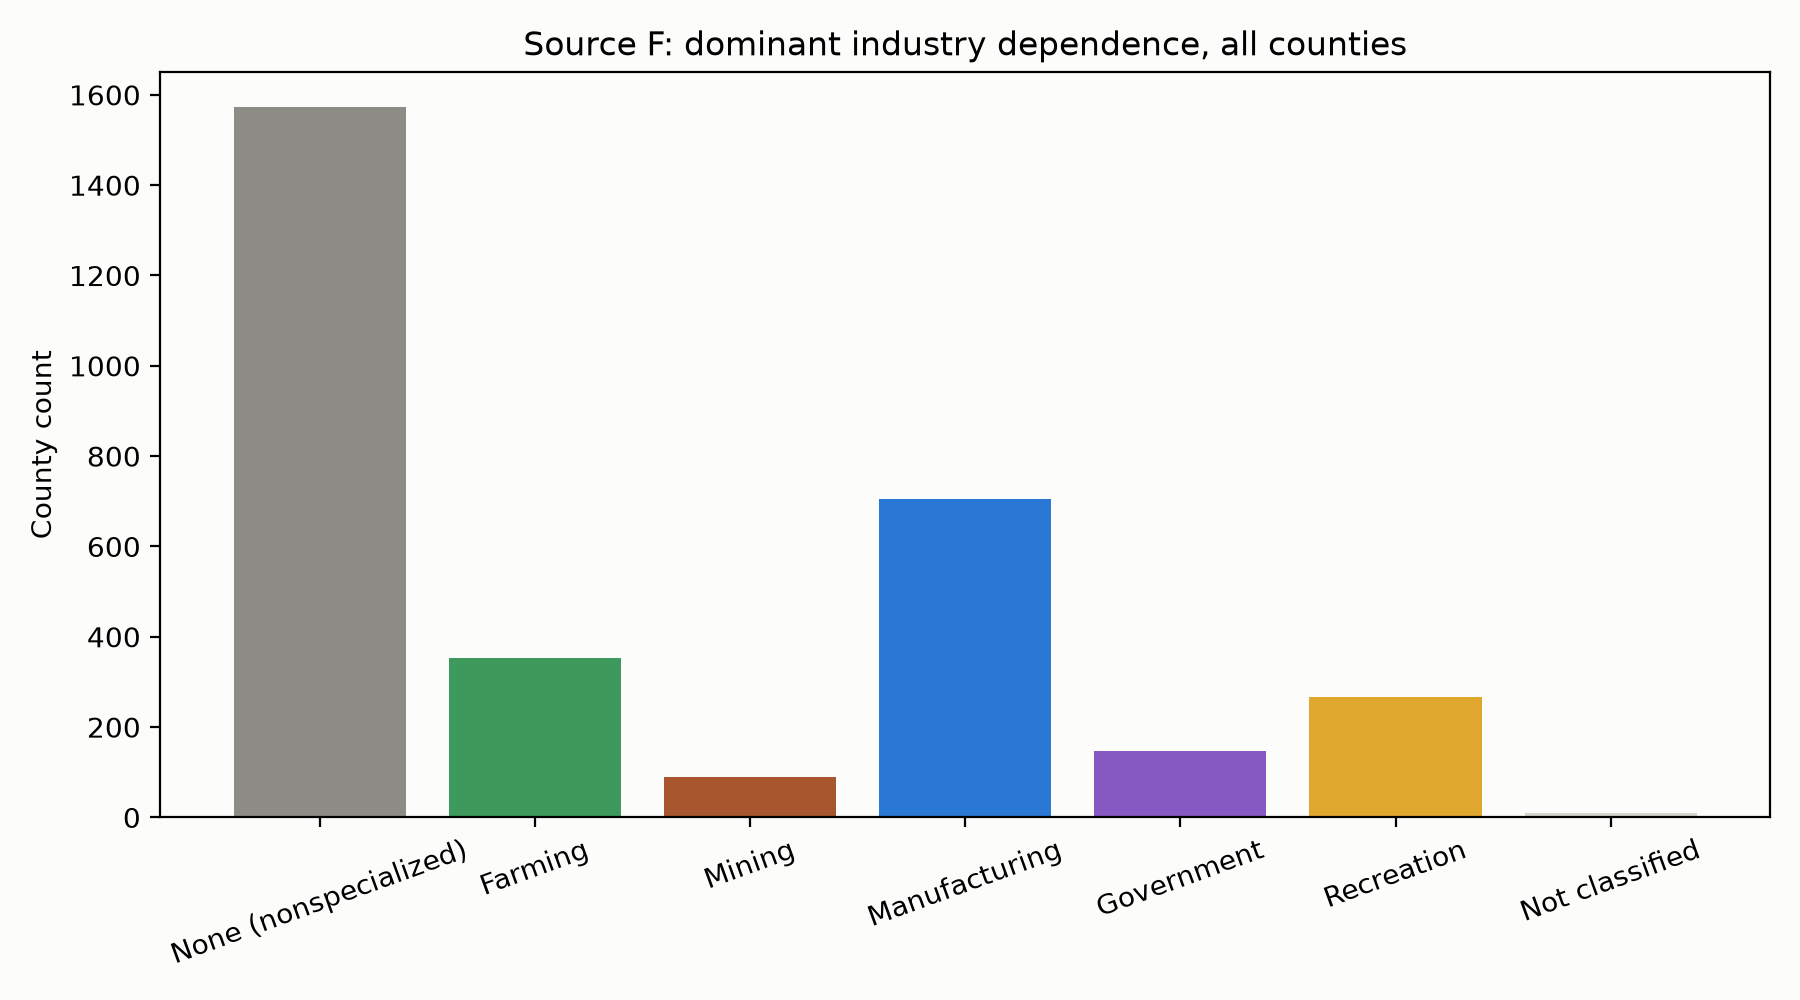

In [3]:
print("Dependence counts:", stats["dependence_counts"])
display(Image(filename=str(FIGURES_DIR / "source-f-figure-01-dependence.png")))

## 3. Finding: The Connecticut Not-Classified Sentinel Matches Source C

All 9 counties carrying ERS's "not classified" sentinel for industry
dependence are Connecticut's new Planning Regions -- the same root cause
`source-c-findings.md` §3.2 independently documents for Source C's missing
GDP series. Two unrelated federal data providers are both still catching up
to Connecticut's 2022 county abolition.

In [4]:
not_classified = source_f_df[source_f_df["nonspecialized"].isna()]
not_classified[["county_name", "metro_2023"]]

,county_name,metro_2023
309,"Capitol Planning Region, Connecticut",True
310,"Greater Bridgeport Planning Region, Connecticut",True
311,Lower Connecticut River Valley Planning Region...,True
312,"Naugatuck Valley Planning Region, Connecticut",True
313,"Northeastern Connecticut Planning Region, Conn...",False
314,"Northwest Hills Planning Region, Connecticut",False
315,"South Central Connecticut Planning Region, Con...",True
316,"Southeastern Connecticut Planning Region, Conn...",True
317,"Western Connecticut Planning Region, Connecticut",True


## 4. Finding: Nonmetro Counties Carry More Compounding Demographic Distress

Summing the six non-exclusive demographic flags into a 0-6 "distress count",
mean distress is 1.069 for nonmetro counties vs. 0.659 for metro counties --
a ~62% relative gap. No county in this vintage carries all 6 flags; the
observed maximum is 5 (17 counties, 0.5%).

Distress distribution: {'0': 1194, '1': 1338, '2': 392, '3': 143, '4': 60, '5': 17}
Mean distress by metro: {'False': 1.069458631256384, 'True': 0.6593591905564924}


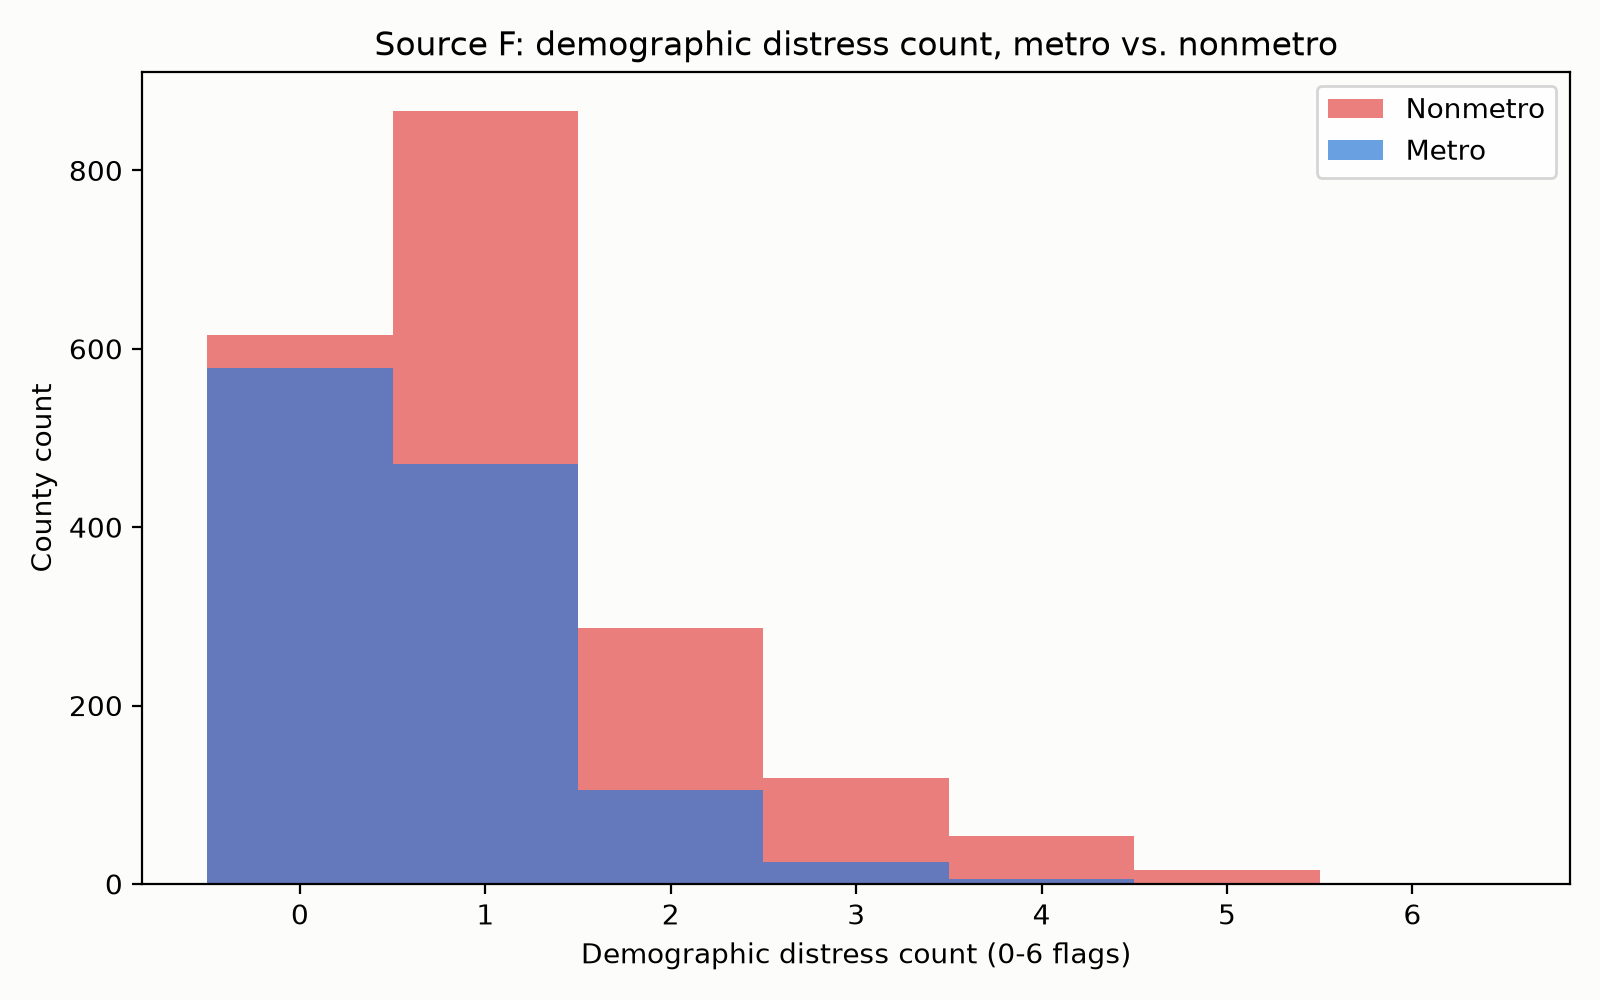

In [5]:
print("Distress distribution:", stats["distress_distribution"])
print("Mean distress by metro:", stats["distress_mean_by_metro"])
display(Image(filename=str(FIGURES_DIR / "source-f-figure-02-distress-distribution.png")))

## 5. Finding: Demographic Distress Does Not Predict Short-Term Velocity

Cross-validating Source F's distress count against Source C's velocity
metrics (size-normalized GDP velocity, since the raw absolute-dollar column
is confounded with economy size) gives a near-zero correlation in both
directions: r = 0.0065 vs. unemployment velocity, r = -0.0189 vs.
size-normalized GDP velocity. Source F captures slow-moving structural
character, not short-run economic momentum -- a genuine, useful negative
result for how these two `E_macro` pillars should be read together.

distress vs. unemployment velocity r = 0.00646059353682839
distress vs. gdp_velocity_pct r = -0.01894000623368352


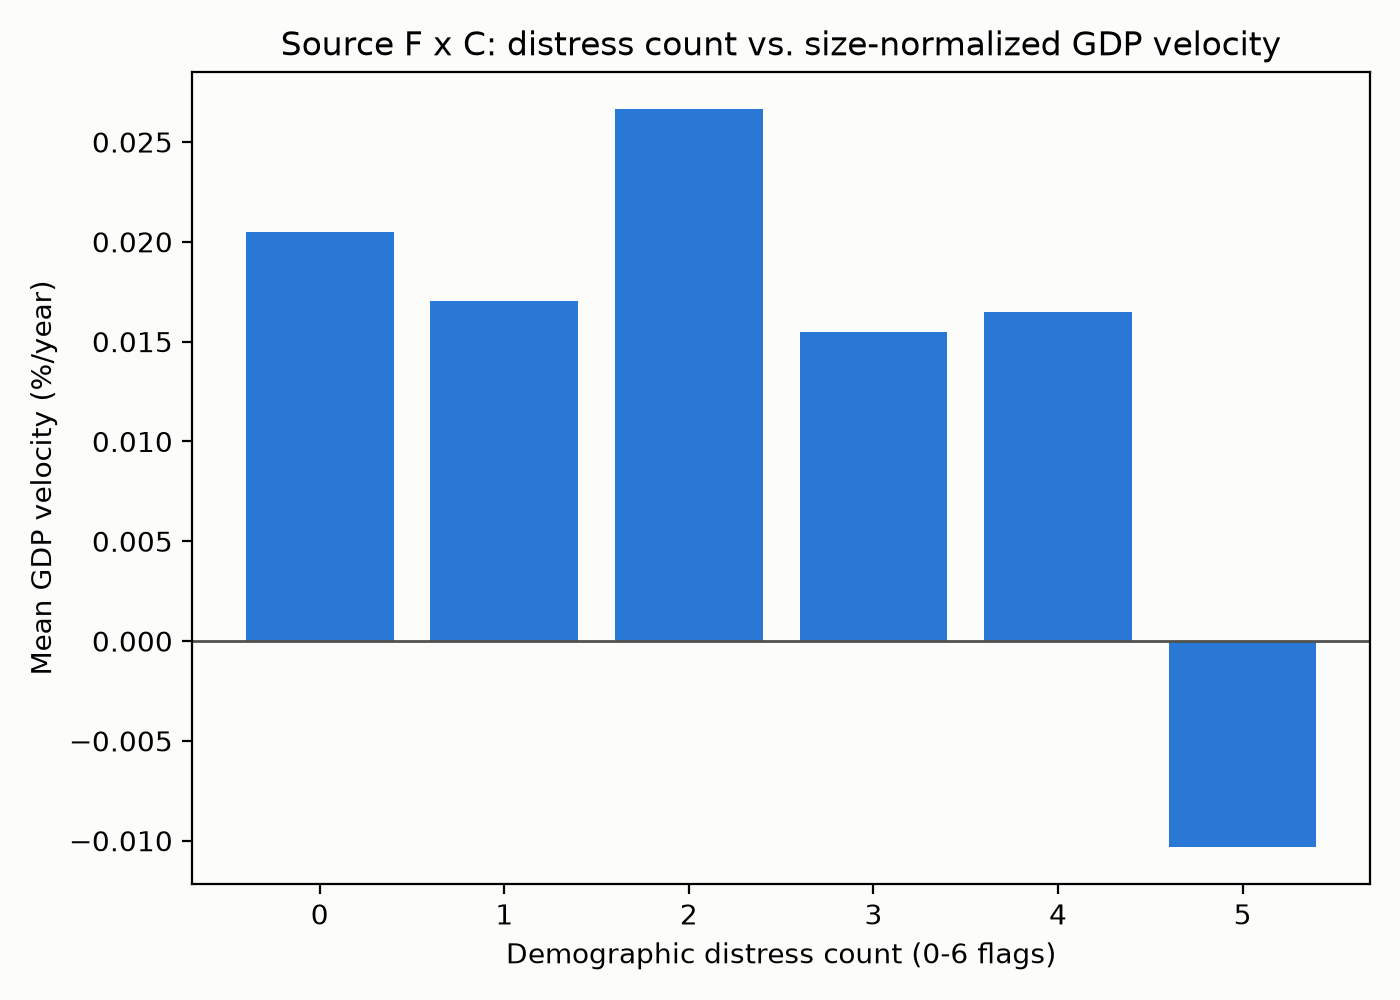

In [6]:
print("distress vs. unemployment velocity r =", stats["distress_vs_unemployment_velocity_corr"])
print("distress vs. gdp_velocity_pct r =", stats["distress_vs_gdp_velocity_pct_corr"])
display(Image(filename=str(FIGURES_DIR / "source-f-figure-03-distress-vs-velocity.png")))

## 6. Limitation: Missing Demographic Flags Are Treated as Absent, Not Unknown

Individual demographic flags carry ERS sentinel nulls for a small number of
counties (up to 33, for `persistent_poverty`). The distress count sums with
`skipna=True`, so a county missing some flags is scored on the remaining
ones rather than penalized or excluded -- a likely slight undercount for the
handful of counties affected. See `source-f-findings.md` §5 for the full
limitations list.

In [7]:
demo_cols = [
    "low_postsecondary_ed", "low_employment", "population_loss",
    "housing_stress", "retirement_destination", "persistent_poverty",
]
source_f_df[demo_cols].isna().sum()

low_postsecondary_ed       0
low_employment             0
population_loss           17
housing_stress             0
retirement_destination     9
persistent_poverty        33
dtype: int64

## 7. Proposal Alignment Summary

See `analysis-output/source-f-findings.md` section 8 for the full assessment.
Short version: the mutually-exclusive dependence mechanism works exactly as
described and ingestion needed none of the accommodations Sources A/C
required, but the proposal's five-category list undersells how large the
"Nonspecialized" residual is (§2), and a second independent data source
hitting the same Connecticut data-lag gap Source C found (§3) is a new,
unanticipated finding worth flagging for future Connecticut-coverage work.